# How to create Template object

The reasons we need Template are:
- to have a place to store all information needed for OCR in both image and patch (bounding-box) levels
- to use all information as a configuration later in OCR process i.e. extracting patches, building prompts, validating extracted results

In [1]:
from bro_ocr.core.template import Dtype, Schema, Patch, Template, SchemaType

In [2]:
invoice_date = Patch(
    name='invoice_date',
    x=440,
    y=110,
    w=541-440,
    h=127-110,
    schema_type=SchemaType.OBJECT,
    schemas=[
        Schema(field='year', dtype=Dtype.INTEGER, instruction='get only year from date'),
        Schema(field='month', dtype=Dtype.INTEGER, instruction='get only month from date'),
        Schema(field='day', dtype=Dtype.INTEGER, instruction='get only day from date'),
    ],
    instruction='original date format is month/day/year'
)

total_amount = Patch(
    name='total_amount',
    x=455,
    y=564,
    w=541-455,
    h=589-564,
    schema_type=SchemaType.SINGLE,
    schemas=[
        Schema(field='total_amount', dtype=Dtype.FLOAT)
    ],
    instruction='amount is in float'
)

items = Patch(
    name='items',
    x=39,
    y=287,
    w=540-39,
    h=564-287,
    schema_type=SchemaType.LIST,
    schemas=[
        Schema(field='description', dtype=Dtype.STRING),
        Schema(field='amount', dtype=Dtype.FLOAT),
    ],
    instruction="billable item description and amount is always in float. if amount is in (...) it's a negative number"
)
template = Template(
    name='a_invoice',
    # instruction='test None',
    w=578,
    h=750,
    patches=[invoice_date, total_amount, items]
)

In [3]:
len(template.patches), template

(3,
 Template(name='a_invoice', instruction=None, w=578, h=750, patches=[Patch(name='invoice_date', x=440, y=110, w=101, h=17, schema_type=<SchemaType.OBJECT: 'object'>, schemas=[Schema(field='year', dtype=<Dtype.INTEGER: 'integer'>, instruction='get only year from date'), Schema(field='month', dtype=<Dtype.INTEGER: 'integer'>, instruction='get only month from date'), Schema(field='day', dtype=<Dtype.INTEGER: 'integer'>, instruction='get only day from date')], instruction='original date format is month/day/year'), Patch(name='total_amount', x=455, y=564, w=86, h=25, schema_type=<SchemaType.SINGLE: 'single'>, schemas=[Schema(field='total_amount', dtype=<Dtype.FLOAT: 'float'>, instruction=None)], instruction='amount is in float'), Patch(name='items', x=39, y=287, w=501, h=277, schema_type=<SchemaType.LIST: 'list'>, schemas=[Schema(field='description', dtype=<Dtype.STRING: 'string'>, instruction=None), Schema(field='amount', dtype=<Dtype.FLOAT: 'float'>, instruction=None)], instruction="b

# How to use SchemasConverter and Template to create pydantic data model

There are two reasons for this class:
- to have a way to create json schema systematically
- to have a way to validate the data extraction

In [4]:
from bro_ocr.utils.conversion import SchemaConverter as sc
from bro_ocr.core.template import SchemaType

SchemaType.SINGLE, SchemaType.OBJECT, SchemaType.LIST

(<SchemaType.SINGLE: 'single'>,
 <SchemaType.OBJECT: 'object'>,
 <SchemaType.LIST: 'list'>)

## single-type data model

In [5]:
total_amount_schema = sc.from_single(
    total_amount.name,
    total_amount.schemas,
)
total_amount_schema

bro_ocr.utils.conversion.total_amount

In [6]:
total_amount.schemas

[Schema(field='total_amount', dtype=<Dtype.FLOAT: 'float'>, instruction=None)]

In [7]:
total_amount_schema(**dict(total_amount=0.1))

total_amount(total_amount=0.1)

## object-type data model

In [8]:
invoice_date_schema = sc.from_object(
    invoice_date.name,
    invoice_date.schemas,
)
invoice_date_schema

bro_ocr.utils.conversion.invoice_date

In [9]:
invoice_date.schemas

[Schema(field='year', dtype=<Dtype.INTEGER: 'integer'>, instruction='get only year from date'),
 Schema(field='month', dtype=<Dtype.INTEGER: 'integer'>, instruction='get only month from date'),
 Schema(field='day', dtype=<Dtype.INTEGER: 'integer'>, instruction='get only day from date')]

In [10]:
invoice_date_schema(**dict(year=2025, month=5, day=10))

invoice_date(year=2025, month=5, day=10)

## list-type data model

In [11]:
items_schema = sc.from_list(
    items.name,
    items.schemas,
)

In [12]:
items.schemas

[Schema(field='description', dtype=<Dtype.STRING: 'string'>, instruction=None),
 Schema(field='amount', dtype=<Dtype.FLOAT: 'float'>, instruction=None)]

In [13]:
items_schema(**{
    "items":[
        {"description": "a", "amount": 1},
        {"description": "b", "amount": 2}
    ]
})

items(items=[items_model(description='a', amount=1.0), items_model(description='b', amount=2.0)])

# How to work with cv2 image

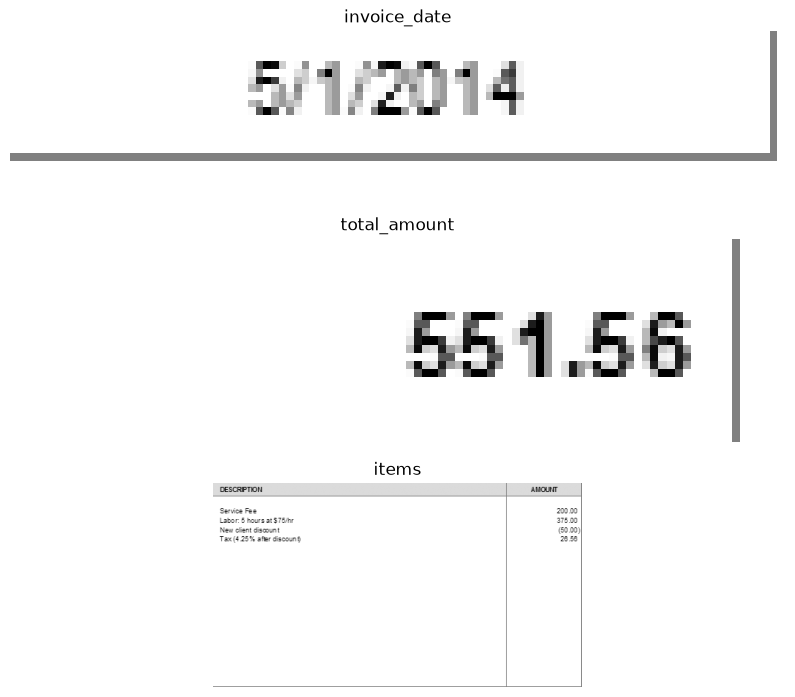

In [14]:
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

base_dir = Path("../examples")
image = cv2.imread(base_dir / "a_invoice.png", cv2.IMREAD_GRAYSCALE)

n = len(template.patches)
fig, axes = plt.subplots(n, 1, figsize=(10, 3*n))
axes = axes.ravel()
for i, patch in enumerate(template.patches):
    patch = template.patches[i]
    plot_image = image[patch.y:patch.y+patch.h, patch.x:patch.x+patch.w]
    axes[i].imshow(plot_image, cmap='gray')
    axes[i].set_title(f"{patch.name}")

for ax in axes.ravel():
    ax.axis('off')
plt.show()

# How to work with LLM featuring AWS Bedrock

You can use any model provider you prefer and create your pipeline as you see fit.  
Here below is one way of doing it. 

Tips:
- you should log model metadata i.e. model name, provider name, run_id, input/output tokens
- you should log prompts and model responses for further analysis
- logging both helps you trace what you've done, so you can improve it along the way

In [15]:
import boto3

class BedrockOCR:
    def __init__(self, model_id, model_region):
        self.bedrock = boto3.client('bedrock-runtime', region_name=model_region)
        self.model_id = model_id

    def __call__(self, patch_prompt:str, image_bytes:bytes, system_prompt:str|None=None)->dict:
        return self._extract(patch_prompt, image_bytes, system_prompt)

    def _extract(self, patch_prompt:str, image_bytes:bytes, system_prompt:str|None=None)->dict:
        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "text": patch_prompt
                    },
                    {
                        "image": {
                            "format": "jpeg",
                            "source": {
                                "bytes": image_bytes
                            }
                        }
                    }
                ]
            }
        ]

        params = {
            'modelId': self.model_id,
            'messages': messages
        }

        if system_prompt:
            params['system'] = [{'text': system_prompt}]

        response = self.bedrock.converse(**params)
        return response

In [16]:
template.patches[0].schemas, template.patches[0].instruction

([Schema(field='year', dtype=<Dtype.INTEGER: 'integer'>, instruction='get only year from date'),
  Schema(field='month', dtype=<Dtype.INTEGER: 'integer'>, instruction='get only month from date'),
  Schema(field='day', dtype=<Dtype.INTEGER: 'integer'>, instruction='get only day from date')],
 'original date format is month/day/year')

In [17]:
from pathlib import Path
import json
import cv2

def extract_json(text: str) -> str:
    decoder = json.JSONDecoder()

    for i, char in enumerate(text):
        if char not in "{[":
            continue

        try:
            _, end = decoder.raw_decode(text[i:])
            return text[i:i + end]

        except json.JSONDecodeError:
            continue

    raise ValueError("No valid JSON found")

def pack_patch_prompt(patch:Patch, data_model):
    system_prompt = patch.instruction
    patch_prompt = (
        f"Extract the content from the following JSON schema:\n{data_model.model_json_schema()}\n"
        f"Return only the extracted information into JSON codeblock start with ```json and end with ```"
    ).strip()
    return system_prompt, patch_prompt

base_dir = Path("../examples")
image = cv2.imread(base_dir / "a_invoice.png")

# using gray scale image is optional
# image = cv2.imread(base_dir / "a_invoice.png", cv2.IMREAD_GRAYSCALE)

# pick any model that works best or fit your budget
# model_id = 'google.gemma-3-4b-it'
model_id = 'qwen.qwen3-vl-235b-a22b'
model_region = 'us-east-1'

bedrock_ocr = BedrockOCR(model_id, model_region)

responses = []
data_models = []
system_prompts = []
patch_prompts = []

for patch in template.patches:
    roi = image[patch.y:patch.y+patch.h, patch.x:patch.x+patch.w]
    success, encoded_image = cv2.imencode(
        ".jpg",
        roi,
        [cv2.IMWRITE_JPEG_QUALITY, 90]
    )
    image_bytes = encoded_image.tobytes()
    if patch.schema_type == SchemaType.SINGLE:
        data_model = sc.from_single(patch.name, patch.schemas)
    elif patch.schema_type == SchemaType.OBJECT:
        data_model = sc.from_object(patch.name, patch.schemas)
    elif patch.schema_type == SchemaType.LIST:
        data_model = sc.from_list(patch.name, patch.schemas)
    else:
        raise ValueError(f"Unknown schema type: {patch.schema_type}")
    system_prompt, patch_prompt = pack_patch_prompt(patch, data_model)
    response = bedrock_ocr(patch_prompt, image_bytes, system_prompt)
    responses.append(response)
    data_models.append(data_model)
    system_prompts.append(system_prompt)
    patch_prompts.append(patch_prompt)
    # break

In [18]:
for res in responses:
    print(res['usage']['inputTokens'])
    print(res['usage']['outputTokens'])
    print(res['output']['message']['content'][0]['text'])

202
31
```json
{
  "year": 2014,
  "month": 5,
  "day": 1
}
```
161
20
```json
{
  "total_amount": 551.56
}
```
321
121
```json
{
  "items": [
    {
      "description": "Service Fee",
      "amount": 200.0
    },
    {
      "description": "Labor: 5 hours at $75/hr",
      "amount": 375.0
    },
    {
      "description": "New client discount",
      "amount": -50.0
    },
    {
      "description": "Tax (4.25% after discount)",
      "amount": 26.56
    }
  ]
}
```


In [19]:
for res, d_model in zip(responses, data_models):
    extracted_str = extract_json(res['output']['message']['content'][0]['text'])
    try:
        d_model.model_validate_json(extracted_str)
    except Exception as e:
        print(e)
        print(extracted_str)

In [20]:
for sp, pp in zip(system_prompts, patch_prompts):
    print(sp, "\n", pp)

original date format is month/day/year 
 Extract the content from the following JSON schema:
{'properties': {'year': {'title': 'Year', 'type': 'integer'}, 'month': {'title': 'Month', 'type': 'integer'}, 'day': {'title': 'Day', 'type': 'integer'}}, 'required': ['year', 'month', 'day'], 'title': 'invoice_date', 'type': 'object'}
Return only the extracted information into JSON codeblock start with ```json and end with ```
amount is in float 
 Extract the content from the following JSON schema:
{'properties': {'total_amount': {'title': 'Total Amount', 'type': 'number'}}, 'required': ['total_amount'], 'title': 'total_amount', 'type': 'object'}
Return only the extracted information into JSON codeblock start with ```json and end with ```
billable item description and amount is always in float. if amount is in (...) it's a negative number 
 Extract the content from the following JSON schema:
{'$defs': {'items_model': {'properties': {'description': {'title': 'Description', 'type': 'string'}, 'a

In [24]:
responses[0]

{'ResponseMetadata': {'RequestId': 'a639b098-4a43-4f9c-828b-79faf1190f4c',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'date': 'Sat, 22 Aug 2026 07:13:21 GMT',
   'content-type': 'application/json',
   'content-length': '272',
   'connection': 'keep-alive',
   'x-amzn-requestid': 'a639b098-4a43-4f9c-828b-79faf1190f4c'},
  'RetryAttempts': 0},
 'output': {'message': {'role': 'assistant',
   'content': [{'text': '```json\n{\n  "year": 2014,\n  "month": 5,\n  "day": 1\n}\n```'}]}},
 'stopReason': 'end_turn',
 'usage': {'inputTokens': 202, 'outputTokens': 31, 'totalTokens': 233},
 'metrics': {'latencyMs': 957}}

In [21]:
from pydantic import BaseModel

class ModelMetadata(BaseModel):
    model_id: str
    model_region: str
    request_id: str
    input_tokens: int
    output_tokens: int
    system_prompt: str
    patch_prompt: str
    success: bool
    error_log: str | None = None

model_metadatas = []

for res, sp, pp, d_model in zip(responses, system_prompts, patch_prompts, data_models):
    request_id = res['ResponseMetadata']['RequestId']
    input_tokens = res['usage']['inputTokens']
    output_tokens = res['usage']['outputTokens']
    extracted_str = extract_json(res['output']['message']['content'][0]['text'])
    try:
        d_model.model_validate_json(extracted_str)
        success = True
        error_log = None
    except Exception as e:
        success = False
        error_log = str(e)

    model_metadata = ModelMetadata(
        model_id=model_id,
        model_region=model_region,
        request_id=request_id,
        input_tokens=input_tokens,
        output_tokens=output_tokens,
        system_prompt=sp,
        patch_prompt=pp,
        success=success,
        error_log=error_log
    )
    model_metadatas.append(model_metadata)

In [23]:
model_metadatas[0].model_dump()

{'model_id': 'qwen.qwen3-vl-235b-a22b',
 'model_region': 'us-east-1',
 'request_id': 'a639b098-4a43-4f9c-828b-79faf1190f4c',
 'input_tokens': 202,
 'output_tokens': 31,
 'system_prompt': 'original date format is month/day/year',
 'patch_prompt': "Extract the content from the following JSON schema:\n{'properties': {'year': {'title': 'Year', 'type': 'integer'}, 'month': {'title': 'Month', 'type': 'integer'}, 'day': {'title': 'Day', 'type': 'integer'}}, 'required': ['year', 'month', 'day'], 'title': 'invoice_date', 'type': 'object'}\nReturn only the extracted information into JSON codeblock start with ```json and end with ```",
 'success': True,
 'error_log': None}